### Init

In [1]:
import sys
sys.path.append('../src/')

In [2]:
from constants import INPT_VARS, EXTRA_VARS, OUT_VARS, GLOBAL_COMBINED_STATS
import hydra
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import logging

from utils.data_utils import (
    get_wet_mask,
    get_train_test_ranges,
    gen_data_in_test,
    gen_data_out_test,
    data_CNN_Lateral,
    data_CNN_Dynamic,
    gen_data_025_lateral,
    gen_data_global_new,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_mean,
    compute_var,
    compute_corrs_area,
    compute_rmse,
    compute_corrs,
    compute_KE,
    compute_time_spec,
    compute_ACC,
    compute_nino34,
    compute_amo,
    gen_KE_spectrum,
    gen_KE,
    gen_KE_range,
    gen_value_range,
    gen_enstrophy_spectrum,
    gen_enstrophy,
    compute_corrs_single,
    compute_ACC_single,
    compute_RMSE_single,
    compute_mean_single,
)
from utils.subgrid_utils import get_area_tensor
from utils.climate_utils import compute_laplacian_wet
from utils.plot_utils import (
    plot_short_time_stats,
    plot_long_time_stats,
    plot_map,
    plot_error_map,
    plot_both_error_map,
    plot_metrics_KE_spectrum,
    plot_metrics_KE,
    plot_metrics_enstrophy_spectrum,
    plot_metrics_entrophy,
    plot_metrics_corr,
    plot_metrics_rmse,
    plot_metrics_acc,
    plot_metrics_mean,
    plot_metrics_pdf,
    get_initial_snapshot_fig,
    plot_region_based_metric,
    plot_diff_map,
)

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import copy
from datetime import datetime
import os

In [3]:
class Eval:
    def __init__(self, args):
        # Getting input, extra input and output
        self.inputs = INPT_VARS[args.exp_num_in]
        self.extra_in = EXTRA_VARS[args.exp_num_extra]
        self.outputs = OUT_VARS[args.exp_num_out]

        self.str_in = "".join([i + "_" for i in self.inputs])
        self.str_ext = "".join([i + "_" for i in self.extra_in])
        self.str_out = "".join([i + "_" for i in self.outputs])

        print("inputs: " + self.str_in)
        print("extra inputs: " + self.str_ext)
        print("outputs: " + self.str_out)

        self.N_atm = len(self.extra_in)  # Number of atmosphere variables
        self.N_in = len(self.inputs)
        if args.lateral:
            self.N_extra = (
                self.N_atm + self.N_in
            )  # Number of atmosphere variables + Lateral boundary variables
        else:
            self.N_extra = self.N_atm  # Number of atmosphere variables
        self.N_out = len(self.outputs)

        self.num_in = int((args.hist + 1) * self.N_in + self.N_extra)

        print("Number of inputs: ", self.num_in)  # 3 (ocean speeds + ocean temp)(t) +
        # 3 (atm wind stresses + atm temp)(t) +
        # 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
        print("Number of outputs: ", self.N_out)  # 3

        # Post-fix strings
        self.str_train = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_out
            + "N_train_4000"
            + "_Lateral_Data_025_no_smooth"
        )
        self.str_save = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_"
            + args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )
        self.post_model_name = (
            "Train_" + args.train_region
            + "_Test_" + args.region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_in
            + "N_train_"
            + str(args.N_samples)
            + "_Lateral_Data_025_no_smooth"
        )
        self.post_pred_name = (
            args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )

        # Getting start and end indices of train and test
        s_train, e_train, e_test = get_train_test_ranges(
            args.N_samples, args.N_val, args.lag, args.hist, args.interval
        )

        # Saving data
        print("Getting inputs")
        if "global_1" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag)
        elif "global_2x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="2x")
        elif "global_4x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="4x")
        else:
            raise NotImplementedError

        print("Calculating mask tensors")
        self.wet, self.wet_nan = get_wet_mask(inputs, "cpu")
        self.wet_bool = np.array(self.wet.cpu()).astype(bool)
        wet_lap = compute_laplacian_wet(self.wet_nan, 4) # hardcoded
        wet_lap = xr.where(wet_lap == 0, 1, np.nan)
        self.wet_lap = np.nan_to_num(wet_lap)
        print("Wet resolution:", self.wet.shape)

        self.time_vec = inputs[0].time.data

        self.time_test = self.time_vec[e_test : (e_test + args.lag * args.N_test)]

        print("Loading Train data")
        train_data = torch.load(
                    Path(args.data_dir) / "train_data_cnn_{0}.pt".format(self.str_train),
                    map_location=torch.device("cpu"),
                )
        self.train_data = train_data
    
        if args.save_test_data:
            print("Saving data")
            data_in_test = gen_data_in_test(
                0, e_test, args.N_test, args.lag, args.hist, inputs, extra_in
            )
            data_out_test = gen_data_out_test(
                0, e_test, args.N_test, args.lag, args.hist, outputs
            )
            if "global" in args.region:
                norm_vals = train_data.norm_vals
                if "combined" in args.train_region:
                    assert len(norm_vals) == len(GLOBAL_COMBINED_STATS) and all(np.array_equal(norm_vals[k], GLOBAL_COMBINED_STATS[k]) for k in norm_vals)
                self.test_data = data_CNN_Dynamic(
                    data_in_test,
                    data_out_test,
                    self.wet.to(device="cpu"),
                    norm_vals,
                    device=args.device,
                )
                # del train_data
            else:
                raise NotImplementedError()
            torch.save(
                self.test_data,
                Path(args.data_dir) / "test_data_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading test data")
            self.test_data = torch.load(
                Path(args.data_dir) / "test_data_cnn_{0}.pt".format(self.str_save)
            )

        # Model
        print("Loading model " + args.network)
        if "swin" in args.network.lower():
            model = instantiate(
                args.swin,
                in_channels=self.num_in,
                output_channels=self.N_in,
                pretrain_img_size=[*self.test_data[0][0].shape[1:]],
                wet=self.wet.cuda()
            )
        elif "unet" in args.network.lower():
            model = instantiate(
                args.unet, wet=self.wet.cuda()
            )

        full_model_path = args.ckpt_path
        self.full_model_name = args.network + "_" + self.post_model_name
        self.output_channels = model.output_channels

        model = model.to(args.device)
        self.ckpt_path = args.ckpt_path
        self.model = model

        # Stats
        self.mean_out = self.test_data.norm_vals["m_out"]
        self.std_out = self.test_data.norm_vals["s_out"]
        self.mean_in = self.test_data.norm_vals["m_in"]
        self.std_in = self.test_data.norm_vals["s_in"]

        # clim
        self.clim = None
        if args.save_clim_data:
            print("Saving clim")
            clim = np.zeros((366, *self.wet.shape, 3))
            for i in range(self.N_out):
                clim[:, :, :, i] = (
                    outputs[i].groupby("time.dayofyear").mean("time").data
                )
            torch.save(
                clim,
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading clim")
            clim = torch.load(
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save)
            )

        self.clim = clim

        # Getting area tensor
        print("Computing area tensor")
        self.grids = xr.open_dataset('/scratch/as15415/Data/CM2x_grids/Grid_New.nc').rename({"dx": "dxu", "dy": "dyu"})

        self.area = torch.from_numpy(self.grids["area_C"].to_numpy()).to(device="cpu")
        self.dx = self.grids["dxu"].to_numpy()
        self.dy = self.grids["dyu"].to_numpy()

        self.pred_model_path = Path(args.path_dir) / self.full_model_name
        if not os.path.isdir(self.pred_model_path):
            os.makedirs(self.pred_model_path)

        self.Nb = args.Nb
        self.hist = args.hist
        self.lag = args.lag
        self.N_test = args.N_test
        self.N_samples = args.N_samples
        self.output_dir = args.output_dir
        self.region = args.region
        self.steps = args.steps
        self.network = args.model_name_replace
        self.inputs = inputs

        self.pred_region = args.region
        self.pred_names = args.pred_names if args.pred_names else []
        self.pred_paths = args.pred_paths if args.pred_paths else [[]]

        self.JUPYTER_MODE = False

    def send_data_to_cpu(self):
        self.test_data.set_device(device="cpu")

### G1, G1

In [4]:
# G1, G1
ConvNext UNet
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_conv_multiseed".format(str(datetime.now())[:10]),
        "model_name_replace=ConvNext UNet",
        "train_region=global_1",
        "region=global_1",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=ConvNext UNet Train1Eval1",
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_2x_seed100/convnext/saved_nets/convnextunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_2x_seed200/convnext/saved_nets/convnextunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=null",
        "pred_paths=null"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

Adam UNet
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_adamunet_global", overrides=[
        "output_dir=./temp/{0}_adam_multiseed".format(str(datetime.now())[:10]),
        "model_name_replace=Adam UNet",
        "train_region=global_1",
        "region=global_1",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=Adam UNet Train1Eval1",
        "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-13-foundation_train_adamunet_global_1/adamunetseed/saved_nets/adamunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_2x_seed100/adam/saved_nets/adamunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_2x_seed200/adam/saved_nets/adamunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=null",
        "pred_paths=null"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

Swin
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_swin_global", overrides=[
        "output_dir=./temp/{0}_swin_multiseed".format(str(datetime.now())[:10]),
        "model_name_replace=Swin",
        "train_region=global_1",
        "region=global_1",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=Swin Train1Eval1",
        "swin.embed_dim=60",
        "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_swintrans60_global_1/swintrans60/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_2x_seed100/swin/saved_nets/swin_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_2x_seed200/swin/saved_nets/swin_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['UNet (Baseline)', 'ConvNext UNet']",
        "pred_paths=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/Adam UNet Train1Eval1_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth]"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model Swin Train1Eval1


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading clim
Computing area tensor


### G1, G2x

In [4]:
# ConvNext UNet
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_conv_multiseed_g1g2x".format(str(datetime.now())[:10]),
        "model_name_replace=ConvNext UNet",
        "train_region=global_1",
        "region=global_2x",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=ConvNext UNet Train1Eval2x",
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_2x_seed100/convnext/saved_nets/convnextunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_2x_seed200/convnext/saved_nets/convnextunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=null",
        "pred_paths=null"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

# Adam UNet
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_adamunet_global", overrides=[
        "output_dir=./temp/{0}_adam_multiseed_g1g2x".format(str(datetime.now())[:10]),
        "model_name_replace=Adam UNet",
        "train_region=global_1",
        "region=global_2x",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=Adam UNet Train1Eval2x",
        "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-13-foundation_train_adamunet_global_1/adamunetseed/saved_nets/adamunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_2x_seed100/adam/saved_nets/adamunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_adamunet_global_1_2x_seed200/adam/saved_nets/adamunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=null",
        "pred_paths=null"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

# Swin
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_swin_global", overrides=[
        "output_dir=./temp/{0}_swin_multiseed_g1g2x".format(str(datetime.now())[:10]),
        "model_name_replace=Swin",
        "train_region=global_1",
        "region=global_2x",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=Swin Train1Eval2x",
        "swin.embed_dim=60",
        "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_swintrans60_global_1/swintrans60/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_2x_seed100/swin/saved_nets/swin_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_2x_seed200/swin/saved_nets/swin_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['UNet (Baseline)', 'ConvNext UNet']",
        "pred_paths=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/Adam UNet Train1Eval2x_Train_global_1_Test_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval2x_Train_global_1_Test_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth]"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model Swin Train1Eval2x


/ext3/miniconda3/envs/emulator/lib/python3.10/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading clim
Computing area tensor


### G1_2x, G_4x

In [ ]:
# ConvNext UNet
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_conv_multiseed_g12x_g4x".format(str(datetime.now())[:10]),
        "model_name_replace=ConvNext UNet",
        "train_region=combined_global_1",
        "region=global_4x",
        "run_gen_pred=True", # Multi-Seed Generation
        "network=ConvNext UNet Train12xEval4x",
        "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-13-foundation_train_adamunet_global_1_2x/adam/saved_nets/adamunet_best_steps_4_global_1_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt, ]",
        "pred_names=null",
        "pred_paths=null"
    ])
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

# Adam UNet
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_adamunet_global", overrides=[
#         "output_dir=./temp/{0}_adam_multiseed_g12x_g4x".format(str(datetime.now())[:10]),
#         "model_name_replace=Adam UNet",
#         "train_region=combined_global_1",
#         "region=global_4x",
#         "run_gen_pred=True", # Multi-Seed Generation
#         "network=Adam UNet Train12xEval4x",
#         "ckpt_path=[]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# Swin
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_swin_global", overrides=[
#         "output_dir=./temp/{0}_swin_multiseed_g12x_g4x".format(str(datetime.now())[:10]),
#         "model_name_replace=Swin",
#         "train_region=combined_global_1",
#         "region=global_4x",
#         "run_gen_pred=True", # Multi-Seed Generation
#         "network=Swin Train12xEval4x",
#         "swin.embed_dim=60",
#         "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
#         "ckpt_path=[]",
#         "pred_names=['UNet (Baseline)', 'ConvNext UNet']",
#         "pred_paths=[]"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

e = Eval(args)

### Generation

In [15]:
def generate_pred_lateral(e):
    print("Generation Pred begin...")
    ns = 4000
    for rand_ind, model_path in enumerate(args.ckpt_path):
        print("Random seed: ", rand_ind+1)
        e.model.load_state_dict(
            torch.load(model_path, map_location=torch.device('cuda'))
        )
        
        model_pred = generate_model_rollout(
            e.N_test,
            e.test_data,
            e.model,
            e.hist,
            e.N_in,
            e.N_extra,
            e.Nb,
            e.region,
        )

        print("data_gen")
        da = xr.DataArray(
            data=model_pred,
            dims=["time", "x", "y", "var"],
        )

        da.to_zarr(
            e.pred_model_path
            / (
                "Pred_lateral_Fast_Data_025_"
                + e.post_pred_name
                + "_rand_seed_"
                + str(rand_ind+1)
                + ".zarr"
            ),
            mode="w",
        )
        print(f"Model pred shape {model_pred.shape}")


In [16]:
if args.run_gen_pred:
    generate_pred_lateral(e)


Generation Pred begin...
Random seed:  1
[[-0.  0.  0.  0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [ 0.  0.  0. -0.  0.]
 [-0. -0.  0.  0.  0.]]
data_gen
Model pred shape (3000, 180, 360, 3)
Random seed:  2
[[ 0.  0.  0.  0.  0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]]
data_gen
Model pred shape (3000, 180, 360, 3)
Random seed:  3
[[-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]
 [-0. -0. -0. -0. -0.]]
data_gen
Model pred shape (3000, 180, 360, 3)


### Loading and Plotting

In [5]:
e.send_data_to_cpu()

def load_seeded_data(Pred_path, e, current_net=False):
    if current_net:
        prefix =  "Pred_lateral_Fast_Data_025_" + e.post_pred_name + "_rand_seed_"
    else:
        prefix = ("Pred_lateral_Fast_Data_025_" 
                    + e.pred_region
                    + "_in_"
                    + e.str_in
                    + "ext_"
                    + "tau_u_tau_v_t_ref_"
                    + "N_samples_"
                    + str(e.N_samples)
                    + "_rand_seed_")

    # model_preds = np.zeros([])
    for rand_seed in range(1,4):
        print("Loading seed ", rand_seed)
        model_pred_net = (
            xr.open_zarr(
                    Path(Pred_path) / (prefix
                    + str(rand_seed)
                    + ".zarr"
                    )
                )
            ).to_array().to_numpy().squeeze()
        
        if rand_seed == 1:
            model_preds = np.repeat(np.expand_dims(np.zeros_like(model_pred_net),axis=0),3,axis=0)
        
        model_preds[rand_seed-1] = model_pred_net

    # model_preds = np.mean(model_preds, axis=0)
    return model_preds

def load_long_data(e):
    print("Load long data...")
    model_pred_net = load_seeded_data(e.pred_model_path, e, True)

    model_pred_saved_nets = []
    if e.pred_paths:
        for model_pred_path in e.pred_paths:
            model_pred_saved_nets.append(
                load_seeded_data(model_pred_path, e, False)
            )
        
    return model_pred_net, model_pred_saved_nets


In [6]:
model_pred_net, model_pred_saved_nets = load_long_data(e)

Load long data...
Loading seed  1
Loading seed  2
Loading seed  3
Loading seed  1
Loading seed  2
Loading seed  3
Loading seed  1
Loading seed  2
Loading seed  3


#### Maps

In [7]:
def compute_corr_map(e, area_flat, pred, truth):
    cor_KE = (area_flat*pred[e.wet_bool].flatten()*truth[e.wet_bool].flatten()).sum()/np.sqrt((area_flat*pred[e.wet_bool].flatten()**2).sum()*(area_flat*truth[e.wet_bool].flatten()**2).sum())
    return cor_KE

def plot_maps(e, model_pred_net, model_pred_saved_nets, start_map=0, N_plot_map=1000, start_error_map=0, N_plot_error_map=1000, long=False):
    print("Getting MAE KE stats...")

    long_KE_net, long_KE_true = gen_KE_range(
        start_error_map, N_plot_error_map, e.test_data, model_pred_net
    )
    _, long_KE_train_true = gen_KE(1000, e.train_data, model_pred_net)
    mse_KE_net = long_KE_net.mean(axis=0) - long_KE_true.mean(axis=0) # np.sqrt(((long_KE_net - long_KE_true)**2).mean(axis=0))
    diff_KE = long_KE_train_true.mean(axis=0) - long_KE_true.mean(axis=0)

    long_mse_KE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_KE_savedi, _ = gen_KE_range(
            start_error_map, N_plot_error_map, e.test_data, model_pred_saved
        )
        mse_KE_savedi = long_KE_savedi.mean(axis=0) - long_KE_true.mean(axis=0) # np.sqrt(((long_KE_savedi - long_KE_true)**2).mean(axis=0))
        long_mse_KE_saved.append(mse_KE_savedi)
    
    long_KE_true = long_KE_true.mean(0)

    print("Plotting MAE KE")
    plot_error_map(
        e.pred_names + [e.network],
        e.region if not long else e.region + '_Long_',
        e.str_save,
        e.output_dir,
        e.grids,
        e.Nb,
        e.wet_nan,
        long_KE_true,
        long_mse_KE_saved + [mse_KE_net],
        "KE",
        e.JUPYTER_MODE
    )

    print("Plotting Diff KE")
    plot_diff_map(
        e.region if not long else e.region + '_Long_',
        e.str_save,
        e.output_dir,
        e.grids,
        e.Nb,
        e.wet_nan,
        long_KE_true,
        diff_KE,
        "KE",
        e.JUPYTER_MODE
    )

    print("Getting temp stats...")

    long_temp_net, long_temp_true = gen_value_range(
        start_error_map, N_plot_error_map, e.test_data, model_pred_net, 2
    )
    _, long_temp_train_true = gen_value_range(0, 1000, e.train_data, model_pred_net, 2)
    # mse_temp_net = np.sqrt(((long_temp_net - long_temp_true)**2).mean(axis=0))
    mse_temp_net = long_temp_net.mean(axis=0) - long_temp_true.mean(axis=0)
    diff_temp = long_temp_train_true.mean(axis=0) - long_temp_true.mean(axis=0)

    

    long_temp_net = long_temp_net.mean(0)

    long_temp_RMSE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        long_temp_savedi, _ = gen_value_range(
            start_error_map, N_plot_error_map, e.test_data, model_pred_saved, 2
        )
        # mse_KE_savedi = np.sqrt(((long_temp_savedi - long_temp_true)**2).mean(axis=0))
        mse_KE_savedi = long_temp_savedi.mean(axis=0) - long_temp_true.mean(axis=0)
        long_temp_RMSE_saved.append(mse_KE_savedi)

    long_temp_true = long_temp_true.mean(0)


    print("Plotting MAE temp map")
    plot_both_error_map(
        e.pred_names + [e.network],
        e.region if not long else e.region + '_Long_',
        e.str_save,
        e.output_dir,
        e.grids,
        e.Nb,
        e.wet_nan,
        long_KE_true,
        long_mse_KE_saved + [mse_KE_net],
        long_temp_true,
        long_temp_RMSE_saved + [mse_temp_net],
        e.JUPYTER_MODE
    )

    print("Plotting Diff Temp")
    plot_diff_map(
        e.region if not long else e.region + '_Long_',
        e.str_save,
        e.output_dir,
        e.grids,
        e.Nb,
        e.wet_nan,
        long_temp_true,
        diff_temp,
        "TEMP",
        e.JUPYTER_MODE
    )

In [8]:
## we can average the results for maps
model_pred_net_averaged = np.mean(model_pred_net, axis=0)
model_pred_saved_nets_averaged = [np.mean(model_pred, axis=0) for model_pred in model_pred_saved_nets]

In [9]:
plot_maps(e, model_pred_net_averaged, model_pred_saved_nets_averaged, start_map=1999, N_plot_map=2999, start_error_map=1999, N_plot_error_map=2999, long=True)

Getting MAE KE stats...
Plotting MAE KE
Plotting Diff KE
Getting temp stats...
Plotting MAE temp map
Plotting Diff Temp


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

#### Timeseries KE

In [10]:
def get_timeseries_KE(e, model_pred_net, model_pred_saved_nets, start=0, N_plot=200, N_plot_spec=200, long=False):
    print("Getting KE stats...")
    KE_net1, KE_true1 = compute_KE(
        N_plot, e.test_data, model_pred_net[0], e.area, e.wet_bool
    )
    KE_net2, KE_true2 = compute_KE(
        N_plot, e.test_data, model_pred_net[1], e.area, e.wet_bool
    )
    KE_net3, KE_true3 = compute_KE(
        N_plot, e.test_data, model_pred_net[2], e.area, e.wet_bool
    )
    KE_net = np.stack([KE_net1,KE_net2,KE_net3])
    KE_true = np.stack([KE_true1,KE_true2,KE_true3])

    KE_saved = []
    for model_pred_saved in model_pred_saved_nets:
        KE_neti1, _ = compute_KE(
            N_plot, e.test_data, model_pred_saved[0], e.area, e.wet_bool
        )
        KE_neti2, _ = compute_KE(
            N_plot, e.test_data, model_pred_saved[1], e.area, e.wet_bool
        )
        KE_neti3, _ = compute_KE(
            N_plot, e.test_data, model_pred_saved[2], e.area, e.wet_bool
        )
        KE_neti = np.stack([KE_neti1,KE_neti2,KE_neti3])
        KE_saved.append(KE_neti)

    return KE_true, KE_saved + [KE_net]

In [11]:
KE_true, KE_saved = get_timeseries_KE(e, model_pred_net, model_pred_saved_nets, start=1999, N_plot=2999, N_plot_spec=1000, long=True)

Getting KE stats...


In [12]:
def plot_metrics_KE_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    KE_true,
    KEs,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(KE_true)

    # KE
    rho = 1020
    for i, KE_i in enumerate(KEs):
        if KE_i is not None:
            plt.plot(
                np.arange(start, end),
                KE_i.mean(axis=0)[start:end] * rho,
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(start, end),
                (KE_i.mean(axis=0)[start:end] - KE_i.std(axis=0)[start:end]) * rho,
                (KE_i.mean(axis=0)[start:end] + KE_i.std(axis=0)[start:end]) * rho,
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(np.arange(start, end), KE_true.mean(axis=0)[start:end] * rho, "--k", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"KE $( J/m^2 )$")
    plt.xlim([start, end])
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(KEs)+1)
    # plt.show()
    plt.savefig(
        Path(output_dir) / ("KE" + region + "_" + save_str + ".png"),
        bbox_inches="tight",
    )
    plt.clf()
    

In [13]:
plot_metrics_KE_seeds(
        e.pred_names + [e.network],
        e.region + '_Long_',
        e.str_save,
        e.output_dir,
        KE_true,
        KE_saved,
    )

<Figure size 640x480 with 0 Axes>

#### Timeseries Temp

In [14]:
def get_timeseries_temperature(e, model_pred_net, model_pred_saved_nets, start=0, N_eval=200, N_eval_ACC=100, long=False):
    ### Spatial matching metrics
    print("Getting Spatial matching stats...")
    T_test = np.array(
        e.test_data[:][1][:, 2] * e.std_out[2] + e.mean_out[2]
    )
    print("Getting Mean...")
    mean_T_net1, mean_T_true1 = compute_mean_single(
        N_eval,
        T_test,
        model_pred_net[0][:, :, :, 2],
        e.area,
        e.wet_bool,
    )
    mean_T_net2, mean_T_true2 = compute_mean_single(
        N_eval,
        T_test,
        model_pred_net[1][:, :, :, 2],
        e.area,
        e.wet_bool,
    )
    mean_T_net3, mean_T_true3 = compute_mean_single(
        N_eval,
        T_test,
        model_pred_net[2][:, :, :, 2],
        e.area,
        e.wet_bool,
    )
    mean_T_net = np.stack([mean_T_net1,mean_T_net2,mean_T_net3])
    mean_T_true = np.stack([mean_T_true1,mean_T_true2,mean_T_true3])
    
    mean_T_saved = []
    for model_pred_saved in model_pred_saved_nets:
        mean_T_i1, _ = compute_mean_single(
            N_eval,
            T_test,
            model_pred_saved[0][:, :, :, 2],
            e.area,
            e.wet_bool,
        )
        mean_T_i2, _ = compute_mean_single(
            N_eval,
            T_test,
            model_pred_saved[1][:, :, :, 2],
            e.area,
            e.wet_bool,
        )
        mean_T_i3, _ = compute_mean_single(
            N_eval,
            T_test,
            model_pred_saved[2][:, :, :, 2],
            e.area,
            e.wet_bool,
        )
        mean_T_i = np.stack([mean_T_i1,mean_T_i2,mean_T_i3])
        mean_T_saved.append(mean_T_i)

    return mean_T_true, mean_T_saved + [mean_T_net]

In [15]:
T_true, T_saved = get_timeseries_temperature(e, model_pred_net, model_pred_saved_nets, start=1999, N_eval=2999, long=True)

Getting Spatial matching stats...
Getting Mean...


In [16]:
def plot_metrics_T_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    T_true,
    Ts,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(T_true)

    rho = 1020
    for i, T_i in enumerate(Ts):
        if T_i is not None:
            plt.plot(
                np.arange(start, end),
                T_i.mean(axis=0)[start:end],
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(start, end),
                T_i.mean(axis=0)[start:end] - T_i.std(axis=0)[start:end],
                T_i.mean(axis=0)[start:end] + T_i.std(axis=0)[start:end],
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(np.arange(start, end), T_true.mean(axis=0)[start:end], "--k", color="dimgrey", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"$\overline{T}$ $( ^\circ C )$")
    plt.xlim([start, end])
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(Ts)+1)
    
    # plt.show()
    
    plt.savefig(
        Path(output_dir) / ("KE" + region + "_" + save_str + ".png"),
        bbox_inches="tight",
    )
    plt.clf()
    

In [17]:
plot_metrics_T_seeds(
        e.pred_names + [e.network],
        e.region + '_Long_',
        e.str_save,
        e.output_dir,
        T_true, 
        T_saved
    )

/state/partition1/job-46886634/ipykernel_799778/945830402.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(np.arange(start, end), T_true.mean(axis=0)[start:end], "--k", color="dimgrey", label="CM2.6")


<Figure size 640x480 with 0 Axes>

#### Indices

In [18]:
def plot_indices(e, model_pred_net, model_pred_saved_nets, long=False):
    print("Getting Nino34...")
    nino_net1, nino_true1 = compute_nino34(
        e.grids,
        e.inputs,
        model_pred_net[0], 
        e.test_data, 
        e.mean_out,
        e.std_out,
        e.time_test
        )
    nino_net2, nino_true2 = compute_nino34(
        e.grids,
        e.inputs,
        model_pred_net[1], 
        e.test_data, 
        e.mean_out,
        e.std_out,
        e.time_test
        )
    nino_net3, nino_true3 = compute_nino34(
        e.grids,
        e.inputs,
        model_pred_net[2], 
        e.test_data, 
        e.mean_out,
        e.std_out,
        e.time_test
        )
    nino_net = np.stack([nino_net1,nino_net2,nino_net3])
    nino_true = np.stack([nino_true1,nino_true2,nino_true3])
    
    nino_saved = []
    for model_pred_saved in model_pred_saved_nets:
        nino_net_i1, _ = compute_nino34(
                            e.grids,
                            e.inputs,
                            model_pred_saved[0], 
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test
                        )
        nino_net_i2, _ = compute_nino34(
                            e.grids,
                            e.inputs,
                            model_pred_saved[1], 
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test
                        )
        nino_net_i3, _ = compute_nino34(
                            e.grids,
                            e.inputs,
                            model_pred_saved[2], 
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test
                        )

        nino_net_i = np.stack([nino_net_i1,nino_net_i2,nino_net_i3])
        nino_saved.append(nino_net_i)

    print("Getting Amo...")
    amo_net1, amo_true1 = compute_amo(e.grids,
                            e.inputs,
                            model_pred_net[0],
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test)
    amo_net2, amo_true2 = compute_amo(e.grids,
                            e.inputs,
                            model_pred_net[1],
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test)
    amo_net3, amo_true3 = compute_amo(e.grids,
                            e.inputs,
                            model_pred_net[2],
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test)
    amo_net = np.stack([amo_net1,amo_net2,amo_net3])
    amo_true = np.stack([amo_true1,amo_true2,amo_true3])
    
    amo_saved = []
    for model_pred_saved in model_pred_saved_nets:
        amo_net_i1, _ = compute_amo(e.grids,
                            e.inputs,
                            model_pred_saved[0],
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test)
        amo_net_i2, _ = compute_amo(e.grids,
                            e.inputs,
                            model_pred_saved[1],
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test)
        amo_net_i3, _ = compute_amo(e.grids,
                            e.inputs,
                            model_pred_saved[2],
                            e.test_data, 
                            e.mean_out,
                            e.std_out,
                            e.time_test)
        amo_net_i = np.stack([amo_net_i1,amo_net_i2,amo_net_i3])
        amo_saved.append(amo_net_i)

    return nino_true, nino_saved + [nino_net], amo_true, amo_saved + [amo_net]

In [19]:
nino_true, nino_saved, amo_true, amo_saved = plot_indices(e, model_pred_net, model_pred_saved_nets, long=True)

Getting Nino34...
Getting Amo...


In [20]:
def plot_index(network_names,
    region,
    save_str,
    output_dir,
    true,
    indices,
    mode='nino34'):

    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(indices[0][0])

    # Indices
    for i, indices_i in enumerate(indices):
        if indices_i is not None:
            plt.plot(
                np.arange(1, N_plot + 1),
                indices_i.mean(axis=0),
                c=clist[i],
                label=f"{network_names[i]}",
            )
            plt.fill_between(
                np.arange(1, N_plot + 1),
                indices_i.mean(axis=0) - indices_i.std(axis=0),
                indices_i.mean(axis=0) + indices_i.std(axis=0),
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    plt.plot(np.arange(1, N_plot + 1), true.mean(axis=0), "--k", label="CM2.6")
    plt.xlabel(r"time $( days )$", fontsize="15")
    y = 'Nino 3.4 Index' if mode == 'nino34' else 'AMO Index'
    plt.ylabel(y, fontsize="15")
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, fontsize="15", ncol=len(indices)+1)
    
    # plt.show()
    
    plt.savefig(
        Path(output_dir) / (y + '_' + region + "_" + save_str + ".png"),
        bbox_inches="tight",
    )
    plt.clf()


In [21]:
print("Plotting Nino34...")
plot_index(
    e.pred_names + [e.network],
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    nino_true,
    nino_saved,
    mode='nino34'
)

print("Plotting Amo...")
plot_index(
    e.pred_names + [e.network],
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    amo_true,
    amo_saved,
    mode='amo'
)

Plotting Nino34...
Plotting Amo...


<Figure size 640x480 with 0 Axes>

#### sensitivity

In [69]:
e.pred_names

['UNet (Baseline)', 'ConvNext UNet']

In [73]:
model_pred_saved_nets[1]

(3, 3000, 180, 360, 3)

In [94]:
def plot_metrics_KE_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    KE_true,
    KEs,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(KE_true)

    # KE
    rho = 1020
    for i, KE_i in enumerate(KEs):
        if i == 0 or i == 1:
            continue
        if KE_i is not None:
            plt.plot(
                np.arange(start, end),
                KE_i[0][start:end] * rho,
                c=clist[0],
                label=f"{network_names[i]}",
            )
            plt.plot(
                np.arange(start, end),
                KE_i[1][start:end] * rho,
                c=clist[1],
                label=f"{network_names[i]}",
            )
            plt.plot(
                np.arange(start, end),
                KE_i[2][start:end] * rho,
                c=clist[2],
                label=f"{network_names[i]}",
            )

    plt.plot(np.arange(start, end), KE_true.mean(axis=0)[start:end] * rho, "--k", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"KE $( J/m^2 )$")
    plt.xlim([start, end])
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(KEs)+1)
    plt.show()
    

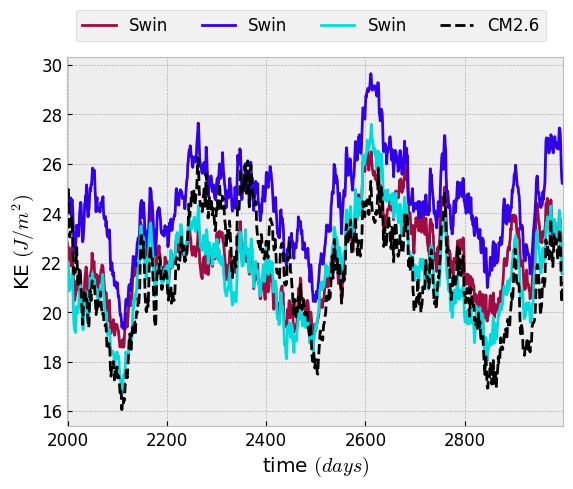

In [95]:
plot_metrics_KE_seeds(
        e.pred_names + [e.network],
        e.region + '_Long_',
        e.str_save,
        e.output_dir,
        KE_true,
        KE_saved,
    )

/state/partition1/job-46884854/ipykernel_2622446/709945289.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.
  plt.plot(np.arange(start, end), T_true.mean(axis=0)[start:end], "--k", color="dimgrey", label="CM2.6")


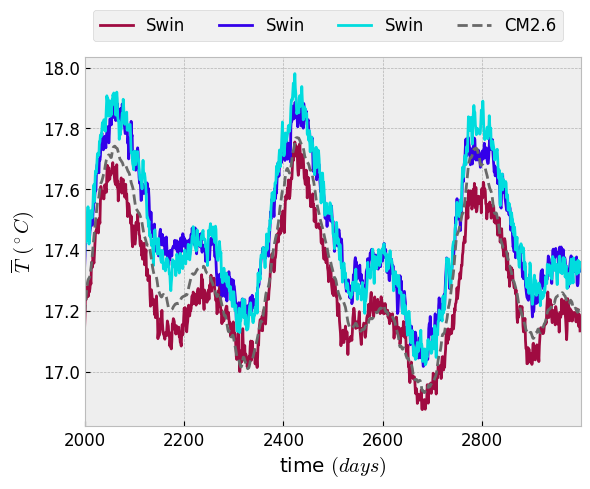

In [98]:
def plot_metrics_T_seeds(
    network_names,
    region,
    save_str,
    output_dir,
    T_true,
    Ts,
    start=1999,
    end=2999,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    N_plot = len(T_true)

    rho = 1020
    for i, T_i in enumerate(Ts):
        if i == 0 or i == 1:
            continue
        if T_i is not None:
            plt.plot(
                np.arange(start, end),
                T_i[0][start:end],
                c=clist[0],
                label=f"{network_names[i]}",
            )
            plt.plot(
                np.arange(start, end),
                T_i[1][start:end],
                c=clist[1],
                label=f"{network_names[i]}",
            )
            plt.plot(
                np.arange(start, end),
                T_i[2][start:end],
                c=clist[2],
                label=f"{network_names[i]}",
            )
            
    plt.plot(np.arange(start, end), T_true.mean(axis=0)[start:end], "--k", color="dimgrey", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"$\overline{T}$ $( ^\circ C )$")
    plt.xlim([start, end])
    plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", fancybox=True, ncol=len(Ts)+1)
    
    plt.show()
    
    
plot_metrics_T_seeds(
        e.pred_names + [e.network],
        e.region + '_Long_',
        e.str_save,
        e.output_dir,
        T_true, 
        T_saved
    )

#### PDF

In [90]:
def get_pdf(e, model_pred_net, model_pred_saved_nets, start=100, N_days=100, long=False):
    # PDF
    print("Getting PDF stats...")
    pdf = {}
    for ind_plot in range(3):
        true_field = (
            e.test_data[start : start + N_days][1][
                :, ind_plot, e.wet_bool
            ].flatten()
            * e.std_out[ind_plot]
        ) + e.mean_out[ind_plot]
        true_pdf, bins_true = np.histogram(true_field, bins=150, density=True)
        bins_true = (bins_true[1:] + bins_true[:-1]) / 2

        field_net = model_pred_net[
            start : start + N_days, e.wet_bool, ind_plot
        ].flatten()
        pdf_net, bins_net = np.histogram(field_net, bins=150, density=True)
        bins_net = (bins_net[1:] + bins_net[:-1]) / 2

        pdf[ind_plot] = {
            "true_pdf": true_pdf,
            "true": [bins_true, true_pdf],
            e.network: [bins_net, pdf_net],
        }

        for i, model_pred_saved in enumerate(model_pred_saved_nets):
            field_i = model_pred_saved[
                start : start + N_days, e.wet_bool, ind_plot
            ].flatten()
            pdf_i, bins_i = np.histogram(field_i, bins=150, density=True)
            bins_i = (bins_i[1:] + bins_i[:-1]) / 2

            pdf[ind_plot][e.pred_names[i]] = [bins_i, pdf_i]

    # KE PDF
    long_KE_net, long_KE_true = gen_KE_range(
        start, N_days, e.test_data, model_pred_net
    )

    true_KE_field = long_KE_true[:, e.wet_bool].flatten()
    true_KE_pdf, bins_KE_true = np.histogram(true_KE_field, bins=150, density=True)
    bins_KE_true = (bins_KE_true[1:] + bins_KE_true[:-1]) / 2

    field_KE_net = long_KE_net[:, e.wet_bool].flatten()
    pdf_KE_net, bins_KE_net = np.histogram(field_KE_net, bins=150, density=True)
    bins_KE_net = (bins_KE_net[1:] + bins_KE_net[:-1]) / 2

    pdf["KE"] = {
            "true_pdf": true_KE_pdf,
            "true": [bins_KE_true, true_KE_pdf],
            e.network: [bins_KE_net, pdf_KE_net],
        }

    for i, model_pred_saved in enumerate(model_pred_saved_nets):
        long_KE_savedi, _ = gen_KE_range(
            start, N_days, e.test_data, model_pred_saved
        )
        field_i = long_KE_savedi[:, e.wet_bool].flatten()
        pdf_i, bins_i = np.histogram(field_i, bins=150, density=True)
        bins_i = (bins_i[1:] + bins_i[:-1]) / 2
        pdf["KE"][e.pred_names[i]] = [bins_i, pdf_i]

    print("Plotting pdf...")
    plot_metrics_pdf(
        e.pred_names + [e.network],
        e.region if not long else e.region + '_Long_',
        e.output_dir,
        pdf,
        e.JUPYTER_MODE
    )